# Discovering the menu — every variant, from inside Python

Tengri is plugin-aware. The library knows what physics it ships, which
inference backends are installed and compatible with a given model,
what filters are on disk, and how to fetch missing SSP grids. Asking
Python is faster than reading docs.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress XLA/PjRt C++ INFO+WARNING logs

import warnings

# Keep the rendered tutorial clean: silence framework notices that do not
# change the science shown here (baked-in nebular, the WavePrecomp blue-band
# approximation, and
# recipe/parameter-provenance notices). Genuine deprecations in user-facing
# calls are fixed in the code, not hidden.
#
# WildcardPartialFreeWarning is deliberately NOT silenced. This notebook is
# about discovering what the menu offers, and that warning is the discovery:
# it names the parameters an `all_params: FREE` wildcard could not free
# because they carry only a Fixed default. Hiding it here would leave a
# reader to meet it for the first time alone, in their own code.
warnings.filterwarnings("ignore", message=".*BakedInBackend.*")
warnings.filterwarnings("ignore", message=".*WavePrecomp.*")
warnings.filterwarnings("ignore", message=".*was marked FIXED.*")
warnings.filterwarnings("ignore", message=".*Composable AGN.*")
warnings.filterwarnings("ignore", message=".*before the Big Bang.*")
warnings.filterwarnings("ignore", category=RuntimeWarning)

import inspect
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np

from _setup import FIG_DIR
import tengri
from tengri import (
    FIXED,
    Observation,
    Photometry,
    SEDModel,
    builders,
    citations,
    plot,
    recipes,
)

plot.setup_style()

## Bird's eye

In [2]:
tengri.summary()


tengri — what's available:

  Core classes (the four nouns inference talks to):
    tengri.SEDModel         differentiable SED forward chain
    tengri.ForwardModel     outer shell — owns SED + observation, exposes .predict / .predict_observables
    tengri.Parameters       priors + fixed values
    tengri.Fitter           inference driver

     7  physics components           tengri.list_components()
     1  AGN models                   tengri.list_agn_models()
    22  dust attenuation laws        tengri.list_dust_laws()
    19  dust emission templates      tengri.list_dust_emission_models()
    27  buildable SFH models         tengri.list_sfh_models(status='production')
    35  total SFH models             tengri.list_sfh_models()
     5  nebular backends             tengri.list_nebular_backends()
   249  photometric filters          tengri.list_filters()
    10  plotting helpers             tengri.list_plots()
     8  primary inference methods    tengri.list_inference_methods(tier=

## SSP catalogs

Bare-stellar grids (e.g. `fsps_prsc_miles_chabrier`) pair with the Cue
nebular emulator; "wNE" grids carry baked-in nebular emission and pair
with the `ssp` nebular backend. `download_ssp` fetches missing grids on
demand.

In [3]:
tengri.list_known_ssps()

name                       filename                    
─────────────────────────  ────────────────────────────
bc03_pdva_stelib_chabrier  bc03_pdva_stelib_chabrier.h5
bpss_stars_c3k_a_chabrier  bpss_stars_c3k_a_chabrier.h5
fsps_bsti_basel_chabrier   fsps_bsti_basel_chabrier.h5 
fsps_bsti_c3k_a_chabrier   fsps_bsti_c3k_a_chabrier.h5 
fsps_bsti_miles_chabrier   fsps_bsti_miles_chabrier.h5 
fsps_mist_basel_chabrier   fsps_mist_basel_chabrier.h5 
fsps_mist_c3k_a_chabrier   fsps_mist_c3k_a_chabrier.h5 
fsps_mist_c3k_a_kroupa     fsps_mist_c3k_a_kroupa.h5   
fsps_mist_c3k_a_salpeter   fsps_mist_c3k_a_salpeter.h5 
fsps_mist_miles_chabrier   fsps_mist_miles_chabrier.h5 
fsps_pdva_basel_chabrier   fsps_pdva_basel_chabrier.h5 
fsps_pdva_c3k_a_chabrier   fsps_pdva_c3k_a_chabrier.h5 
fsps_pdva_miles_chabrier   fsps_pdva_miles_chabrier.h5 
fsps_prsc_basel_chabrier   fsps_prsc_basel_chabrier.h5 
fsps_prsc_c3k_a_chabrier   fsps_prsc_c3k_a_chabrier.h5 
fsps_prsc_c3k_a_kroupa     fsps_prsc_c3k_a_kroup

In [4]:
ssp = tengri.load_ssp("fsps_prsc_miles_chabrier", download=True)

## Star-formation history variants

Each entry of `builders.sfh.available()` is a real callable whose
signature lists its parameters with default priors. Notebook
autocompletion works on it.

In [5]:
builders.sfh.available()

['buat08',
 'burst',
 'const',
 'const_exp',
 'continuity',
 'continuity_flex',
 'declining_exp',
 'delayed',
 'delayed_bq',
 'dense_basis',
 'dense_basis_pure',
 'dexp',
 'dirichlet',
 'dpl',
 'exp',
 'field',
 'lnorm',
 'norm',
 'periodic',
 'psb',
 'psb_suess2022',
 'sfh2exp',
 'snorm',
 'snorm_burst',
 'table',
 'tsnorm',
 'tsnorm_burst']

In [6]:
print(inspect.signature(builders.sfh.dpl))

(*, defaults: Any = FIXED, alpha: Any = <object object at 0x11fe36f60>, beta: Any = <object object at 0x11fe36f60>, tau_gyr: Any = <object object at 0x11fe36f60>, age_gyr: Any = <object object at 0x11fe36f60>, log_total_mass: Any = <object object at 0x11fe36f60>) -> dict


Two SFHs at the same mass, side by side:

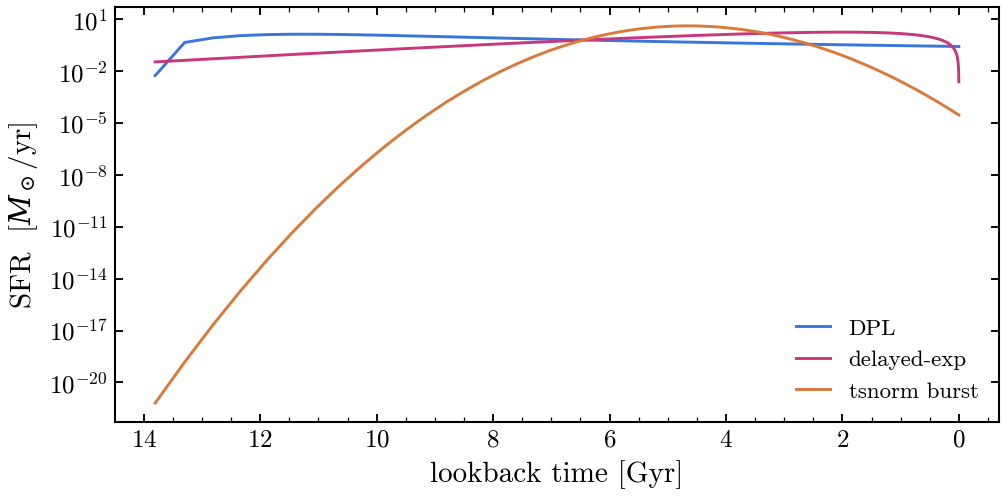

In [7]:
obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "wise_w1"])
)


def _build_sfh(sfh_factory):
    return SEDModel.build(
        ssp_data=ssp,
        observation=obs,
        sfh=sfh_factory(defaults=FIXED),
        dust={"type": "two_component", "law_bc": "calzetti", "all_params": FIXED},
        neb={"type": "none"},
        redshift=0.05,
    )


fig, ax = plt.subplots(figsize=(7, 3.6))
for name, factory, color in [
    ("DPL", builders.sfh.dpl, "#3a76d9"),
    ("delayed-exp", builders.sfh.dexp, "#c8377d"),
    ("tsnorm burst", builders.sfh.tsnorm, "#d97a3a"),
]:
    m = _build_sfh(factory)
    p = m.spec.sample(jax.random.PRNGKey(0))
    p = {**m.spec.get_fixed_values(), **p}
    s = m.predict_state(p)
    lbt_gyr = np.asarray(s.derived["sfh_grid_lbt_yr"]) / 1e9
    sfr = np.asarray(s.derived["sfr_history"])
    ax.plot(lbt_gyr, sfr, color=color, lw=1.4, label=name)
ax.invert_xaxis()
ax.set_xlabel("lookback time [Gyr]")
ax.set_ylabel(r"SFR  [$M_\odot$/yr]")
ax.set_yscale("log")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_sfh_variants.png", dpi=300, bbox_inches="tight")

## Dust laws and IR templates

Attenuation laws — Calzetti, Cardelli (MW/LMC/SMC), Prevot SMC, Li 2008,
Witt & Gordon 2000, Conroy/Charlot–Fall variants — and IR re-emission
templates (Dale 2014, Draine–Li, THEMIS, Astrodust, BOSA, Casey 2012,
modified blackbody) all live under `tengri.components.dust`.

In [8]:
tengri.list_dust_laws()

name          status      citation                                           short_doc                                             
────────────  ──────────  ─────────────────────────────────────────────────  ──────────────────────────────────────────────────────
calzetti      production  Calzetti et al. 2000 (ApJ 533, 682)                Calzetti et al. starburst attenuation (R_V=4.05)      
cardelli      production  Cardelli et al. 1989 (ApJ 345, 245) MW extinction  Cardelli et al. MW extinction (parameterized R_V)     
conroy2010    production  Conroy et al. 2010 (ApJ 708, 58)                   Conroy+10 mixed MW + power-law (FSPS default)         
d03_mwrv31    production  Draine 2003 (ARA&A 41, 241)                        Draine 2003 MW R_V=3.1 grain model attenuation        
hd23_mwrv31   production  Hensley & Draine 2023 (ApJ 948, 55)                Hensley & Draine 2023 astrodust+PAH grain model       
kriek_conroy  production  Kriek & Conroy 2013 (ApJL 775, L16)               

In [9]:
tengri.list_dust_emission_models()

name                  status        citation                                                             short_doc                                                              
────────────────────  ────────────  ───────────────────────────────────────────────────────────────────  ───────────────────────────────────────────────────────────────────────
astrodust             experimental  Hensley & Draine 2023 (ApJ 948, 55)                                  Astrodust + PAH unified grain model                                    
bosa                  experimental  Boquien et al. 2019 (CIGALE BOSA grids)                              BOSA dust SED templates                                                
casey2012             production    Casey 2012 (MNRAS 425, 3094)                                         Modified blackbody + mid-IR power law (analytic)                       
dale2014              production    Dale et al. 2014 (ApJ 784, 83)                                       SFR-driven

## Nebular backends

- **`cue`** — neural emulator on Cloudy 17.03 (Li+2024). Fast, smooth,
  requires bare-stellar SSP.
- **`ssp`** — baked-in nebular contribution from a wNE SSP grid.
  Cheapest, locked to grid choices.
- **`cloudy`** — direct Cloudy evaluation. Accurate, slow.
- **`none`** — disable.

In [10]:
tengri.list_nebular_backends()

name    status      citation                                                  short_doc                                                          
──────  ──────────  ────────────────────────────────────────────────────────  ───────────────────────────────────────────────────────────────────
cb19    production  Charlot & Bruzual 2019 / Martinez-Paredes+2023 (3MdB_17)  6D CB19 lines-only nebular grid (CB19Backend)                      
cloudy  production  Byler+2017 / Cloudy grids                                 Trilinear interp on Cloudy photoionization grid (CloudyGridBackend)
cue     production  Li et al. 2025 (CUE neural emulator)                      Neural-network Cloudy emulator with 12 free params (CueBackend)    
none    production                                                            Disable nebular emission (continuum + lines)                       
ssp     production  DSPS / FSPS SSP-internal                                  Emission baked into SSP grid; zero free params

## AGN composables

AGN is built from six orthogonal stages — disc, nlr, blr, feii, torus,
attenuation — each with its own registry of swappable blocks. The
composable blocks are the recommended surface for mixing and matching AGN
components. `recipes.agn_panchromatic()` is one stable composition.

In [11]:
tengri.list_agn_models()

name        status      citation                                                          short_doc                                                                 param_details                                                                   
──────────  ──────────  ────────────────────────────────────────────────────────────────  ────────────────────────────────────────────────────────────────────────  ────────────────────────────────────────────────────────────────────────────────
composable  production  (no single paper — block recipe of registered tengri AGN blocks)  Composable AGN: pick one block per stage (disc/nlr/blr/feii/torus/atten)  [{'name': 'agn_log_lbol', 'default': 'Uniform(8.0, 14.0)', 'description': 'AG...
[1 result — agn_model]
  Use:  tengri.describe('composable')  →  SEDModel.build(..., agn={'type': 'composable'})

### Composable AGN blocks — discovery and mixing

The composable grammar groups blocks by pipeline stage. Use
`list_agn_blocks()` to see all available options, grouped by category.
Each block has a citation, status, and description accessible via
`describe_agn_block()`.

In [12]:
tengri.list_agn_blocks()

name                          status        citation                                                                          short_doc                                                              category   
────────────────────────────  ────────────  ────────────────────────────────────────────────────────────────────────────────  ─────────────────────────────────────────────────────────────────────  ───────────
grahsp_biatten                production    Buchner et al. 2024, arXiv:2405.19297                                             GRAHSP SMC-like broken power-law bi-attenuation                        attenuation
none                          production                                                                                                                                                             attenuation
polar_dust                    production    Pei 1992, ApJ, 395, 130                                                           Polar-dust extinction with Type-1-only

In [13]:
# Inspect a specific block
tengri.describe_agn_block("skirtor", category="torus")

name,skirtor
category,torus
kind,agn_block
status,production
citation,"Stalevski et al. 2016, MNRAS, 458, 2288"
short_doc,Stalevski et al. 2016 SKIRTOR torus with polar dust
use,"SEDModel.build(..., agn={'torus': {'type': 'skirtor'}})"


## Recipes — five curated starting points

In [14]:
print(list(recipes.__all__))

['agn_panchromatic', 'composable_agn', 'dust_demo', 'high_z', 'mock_recovery_minimal', 'photoz', 'quiescent_z0', 'star_forming_photometry', 'stochastic_sfh_jwst', 'unified_agn']


In [15]:
recipes.star_forming_photometry()

{'sfh': {'type': 'dpl', 'all_params': FREE},
 'dust': {'type': 'two_component',
  'all_params': FREE,
  'law_bc': 'calzetti',
  'law_diff': 'calzetti',
  'emission': {'type': 'dale2014', 'all_params': FIXED}},
 'neb': {'type': 'cue', 'all_params': FIXED},
 'redshift': Uniform(0.01, 6.0),
 'apply_igm': True,
 'approx': WavePrecomp(n_z=250, z_min=None, z_max=None, catalog_z_range=None, band_integration='quadrature', n_subbands=5, taylor_correction=False, fast_dust_emission=False)}

## Inference backends

The `status` column reports whether each backend's dependencies are
importable. Compatibility against a specific model is rechecked at
`Fitter.run` time.

In [16]:
tengri.list_inference_methods()

name                 tier          status  short_doc                                                                       
───────────────────  ────────────  ──────  ────────────────────────────────────────────────────────────────────────────────
laplace              primary       ok      Laplace approximation around the MAP (cold ~5-9s, warm ~1-2s, ~3 GB)            
map                  primary       ok      Adam MAP optimization                                                           
mcmc                 primary       ok      Auto MCMC: NUTS for low-D, raytrace for high-D                                  
mcmc_hmc             primary       ok      Hamiltonian Monte Carlo (cold ~21s, ~5 GB on D=6-7). Convergence-validated on...
mcmc_nuts            primary       ok      No-U-Turn Sampler (cold ~90s at D=6 DPL; warmup blows past 5 min on dense_bas...
mcmc_raytrace        primary       ok      Ray-tracing ensemble sampler (high-D)                                           
vi      


## All registries at a glance

`list_all()` returns the master catalog of every registry in tengri.

In [17]:
tengri.list_all()

{'inference_methods': name                 tier          status  short_doc                                                                       
 ───────────────────  ────────────  ──────  ────────────────────────────────────────────────────────────────────────────────
 laplace              primary       ok      Laplace approximation around the MAP (cold ~5-9s, warm ~1-2s, ~3 GB)            
 map                  primary       ok      Adam MAP optimization                                                           
 mcmc                 primary       ok      Auto MCMC: NUTS for low-D, raytrace for high-D                                  
 mcmc_hmc             primary       ok      Hamiltonian Monte Carlo (cold ~21s, ~5 GB on D=6-7). Convergence-validated on...
 mcmc_nuts            primary       ok      No-U-Turn Sampler (cold ~90s at D=6 DPL; warmup blows past 5 min on dense_bas...
 mcmc_raytrace        primary       ok      Ray-tracing ensemble sampler (high-D)                       

### Star-formation history models

Thirty-five SFH variants span parametric (exponentials, delayed-τ, power-laws)
and non-parametric (spline, Dirichlet, dense basis) families. **Eight of these
are marked `status='unvalidated'`: they are registered but not yet validated
against the DSPS forward path.** Attempting to use an unvalidated SFH raises
`ValueError("SFH type '...' is registered but not yet validated against the
DSPS forward path, so it is not available via the builder...")`. Use the
`status` column to filter the menu.

In [18]:
tengri.list_sfh_models()

name                       status       citation                                                       short_doc                                                                         param_details                                                                   
─────────────────────────  ───────────  ─────────────────────────────────────────────────────────────  ────────────────────────────────────────────────────────────────────────────────  ────────────────────────────────────────────────────────────────────────────────
buat08                     production   Buat et al. 2008                                               Velocity-parameterized SFH (Buat et al.)                                          [{'name': 'sfh_buat08_log_total_mass', 'default': 'Uniform(7.0, 12.5)', 'desc...
burst                      production                                                                  Triweight burst kernel (Zacharegkas+2025)                                         [{'name': 'sfh_bu

### Metallicity modes

Per-bin, continuity-aware, chemical evolution, gas regulator, and tabulated Z(t).

In [19]:
tengri.list_metallicity_modes()

name             status      citation  short_doc                                            
───────────────  ──────────  ────────  ─────────────────────────────────────────────────────
bins             production            Per-bin metallicities (pairs with continuity SFH)    
bins_continuity  production            Cumulative delta-log-Z steps                         
chem_evol        production            Gas-regulator model (Z derived from SFH)             
delta            production            Single metallicity (the default)                     
massmap_box      production            Closed-box metallicity tied to cumulative mass formed
massmap_lin      production            Linear metallicity tied to cumulative mass formed    
psb_two_step     production            Step at post-starburst burst age                     
ramp             production            Linear evolving metallicity                          
table            production            User-provided Z(t)             

### Intergalactic absorption (IGM)

In [20]:
tengri.list_igm_models()

name       status      citation                       short_doc                                                                      
─────────  ──────────  ─────────────────────────────  ───────────────────────────────────────────────────────────────────────────────
asada25    production  Asada+2025 (ApJL 983, L2)      Inoue+2014 IGM + Asada+2025 proximate-CGM damping wing (fixes z>7 photo-z bias)
inoue      production  Inoue+2014 (MNRAS 442, 1805)   Alias of 'inoue14' kept for backwards compatibility                            
inoue14    production  Inoue+2014 (MNRAS 442, 1805)   Mean LyC + Lyman-series IGM attenuation; default for z >~ 1                    
madau      production  Madau 1995 (ApJ 441, 18)       Original Lyman-forest mean transmission                                        
meiksin06  production  Meiksin 2006 (MNRAS 365, 807)  Smooth Ly-alpha forest continuum + LLS damping (matches CIGALE)                
none       production                                 Disable 

### X-ray emission

In [21]:
tengri.list_xray_models()

name             status      citation                                                               short_doc                                                                  
───────────────  ──────────  ─────────────────────────────────────────────────────────────────────  ───────────────────────────────────────────────────────────────────────────
agn_xray_corona  production                                                                         SEDComponent for AGN X-ray corona emission.                                
lopez24          production  Lopez et al. 2024 (A&A 692, A209); Asmus et al. 2015 (MNRAS 454, 766)  IR-tied AGN corona via alpha_IRX(L_12um) + Lehmer+16 XRBs + hot gas        
none             production                                                                         Disable X-ray emission                                                     
simple           production  Yang+2020 / X-CIGALE (MNRAS 491, 740)                                  AGN corona via alpha

### Radio emission and blocks

In [22]:
tengri.list_radio_models()

name            status      citation                                                  short_doc                                                              
──────────────  ──────────  ────────────────────────────────────────────────────────  ───────────────────────────────────────────────────────────────────────
condon92        production  Condon 1992 (ARA&A 30, 575) + Yang+2020 (MNRAS 491, 740)  FIR-radio correlation (q_IR) + AGN radio loudness power-law            
none            production                                                            Disable radio emission                                                 
radio_dpl       production                                                            Radio synchrotron + free-free + AGN double-power-law with aging cutoff.
radio_powerlaw  production                                                            SEDComponent for radio synchrotron (power-law) + thermal emission.     
[4 results — radio_model]
  Use:  tengri.describe('c

In [23]:
tengri.list_radio_blocks()

name            status      citation                                                short_doc                                            category
──────────────  ──────────  ──────────────────────────────────────────────────────  ───────────────────────────────────────────────────  ────────
dpl             production  Martinez-Ramirez+2024 (A&A 692, A85)                    Broken double power-law with exp aging cutoff        agn     
none            production                                                          No AGN radio (star-forming synchrotron only)         agn     
powerlaw        production                                                          Single power-law AGN radio scaled by radio-loudness  agn     
bell2003        production  Bell 2003 (ApJ 586, 794)                                Fixed-q FIR-radio correlation                        sf      
delvecchio2021  production  Delvecchio+2021 FIRRC (SEMPER Eq. 4, arXiv:2503.20525)  Mass- and z-dependent q_IR at 1.4 GHz   

### Shock nebular emission

In [24]:
tengri.list_shock_models()

name      status      citation                                                            short_doc                                                       
────────  ──────────  ──────────────────────────────────────────────────────────────────  ────────────────────────────────────────────────────────────────
mappings  production  Allen+2008 (ApJS 178, 20); Sutherland & Dopita 2017 (ApJS 229, 34)  MAPPINGS shock + precursor emission, additive to any neb backend
none      production                                                                      No shock component                                              
[2 results — shock_model]
  Use:  tengri.describe('mappings')  →  SEDModel.build(..., shock={'type': 'mappings'})

### Dust emission templates

In [25]:
tengri.list_dust_models()

name              status      citation                             short_doc                                                   
────────────────  ──────────  ───────────────────────────────────  ────────────────────────────────────────────────────────────
single_component  production  Calzetti et al. 2000 (ApJ 533, 682)  One screen over all stars; `law_bc` sets the curve          
two_component     production  Charlot & Fall 2000 (ApJ 539, 718)   Birth-cloud + diffuse screens; young stars see both         
wg00              production  Witt & Gordon 2000 (ApJ 528, 799)    Radiative-transfer grid (geometry/structure/curve selectors)
[3 results — dust_model]
  Use:  tengri.describe('single_component')  →  SEDModel.build(..., dust={'type': 'single_component'})

### Age integration kernels

Cloud-in-cell (default, default, dense integrand) and DSPS histogram kernel for SFH→CSP composition.

In [26]:
tengri.list_age_kernels()

name  status      citation    short_doc                                                                
────  ──────────  ──────────  ─────────────────────────────────────────────────────────────────────────
cic   production              Cloud-in-cell on a 16x dense integrand — the accuracy default (#964)     
dsps  comparison  hearin2021  DSPS histogram kernel — cross-code parity only; biases optical CSP +1.2 %
[2 results — age_kernel]
  Use:  tengri.describe('cic')  →  SEDModel.build(sfh={'age_kernel': 'cic'})

### All SED components

In [27]:
tengri.list_components()

name     status      short_doc                                                                 
───────  ──────────  ──────────────────────────────────────────────────────────────────────────
stellar  production  SSP integration over SFH (DSPS), metallicity history, mass remaining      
dust     production  Two-component attenuation (BC + diffuse); see list_dust_laws()            
agn      production  Disc + torus + polar dust + BLR/NLR; see list_agn_models / list_agn_blocks
nebular  production  Emission lines + continuum — BakedIn / CUE / CloudyGrid / CB19            
radio    production  SF synchrotron + AGN jets + free-free continuum                           
igm      production  IGM transmission (Inoue+2014) + DLA absorption                            
xray     production  X-ray binaries + AGN corona                                               
[7 results — component]
  Use:  tengri.describe('stellar')  →  tengri.stellar

### All instruments and filters

Instruments group filters by survey or facility; 249 filter curves span UV to radio.
Display sample surveys:

In [28]:
tengri.list_instruments()

name          n_bands  description                                                         
────────────  ───────  ────────────────────────────────────────────────────────────────────
GALEX         2        GALEX FUV + NUV; the canonical low-z UV set.                        
SDSS          5        SDSS ugriz; the canonical low-z optical photometric set.            
2MASS         3        2MASS JHKs near-infrared.                                           
UKIDSS        5        UKIDSS ZYJHK near-infrared.                                         
WISE          4        WISE W1–W4 mid-IR.                                                  
Spitzer_IRAC  4        Spitzer IRAC 3.6/4.5/5.8/8.0 µm.                                    
Herschel      5        Herschel PACS 100/160 + SPIRE 250/350/500 µm.                       
HST_ACS_WFC3  9        HST ACS optical + WFC3 NIR; the workhorse high-z imaging set.       
JWST_NIRCam   8        JWST NIRCam wide bands (F070W–F444W); the canonical JADES

In [29]:
tengri.list_filters().filter(survey="SDSS")

name          survey  instrument  band  alias 
────────────  ──────  ──────────  ────  ──────
SLOAN_SDSS_g  SLOAN   SDSS        g     sdss_g
SLOAN_SDSS_i  SLOAN   SDSS        i     sdss_i
SLOAN_SDSS_r  SLOAN   SDSS        r     sdss_r
SLOAN_SDSS_u  SLOAN   SDSS        u     sdss_u
SLOAN_SDSS_z  SLOAN   SDSS        z     sdss_z
[5 results — filter]
  Use:  tengri.describe('SLOAN_SDSS_g')  →  Photometry.from_names(["SLOAN_SDSS_g"])

### Diagnostic and publication plots

In [30]:
tengri.list_plots()

name                    status      short_doc                                                           
──────────────────────  ──────────  ────────────────────────────────────────────────────────────────────
plot_sed_fit            production  Plot observed photometry/spectrum + posterior SED + uncertainty band
plot_spectrum_fit       production  Plot spectrum + posterior model with calibration polynomial         
plot_sfh                production  Plot single SFH(t) curve from a Parameters / Posterior              
plot_sfh_comparison     production  Overlay multiple SFH(t) curves (e.g. truth vs posterior)            
plot_corner_comparison  production  Two-posterior corner plot (e.g. with truth)                         
safe_corner             production  Corner plot wrapper that handles fixed parameters gracefully        
plot_1d_posterior       production  Marginal histogram of one parameter + median/16/84                  
plot_calibration        production  Chebyshev calibrati

### Recipes — full registry

In [31]:
tengri.list_recipes()

name                     short_doc                                                                ssp_requirement                                                                   data                                                                  
───────────────────────  ───────────────────────────────────────────────────────────────────────  ────────────────────────────────────────────────────────────────────────────────  ──────────────────────────────────────────────────────────────────────
agn_panchromatic         Recipe for AGN-dominated galaxies with multi-wavelength data.            bare-stellar (Cue nebular backend; see star_forming_photometry for details).      ready                                                                 
composable_agn           Fully composable AGN — all slots switchable on committed data.           bare-stellar (Cue nebular backend; see star_forming_photometry for details).      ready                                                              


## Parameter and physics provenance

Two introspection surfaces close the loop:
`model.spec.summary()` tags every parameter with where its value came
from (`[user]` / `[all_params FREE]` / `[all_params FIXED]` / `[default]`).
`citations.collect_citations(model)` returns the bibliography of every
physics ingredient.

In [32]:
example = SEDModel.build(ssp_data=ssp, observation=obs, **recipes.star_forming_photometry())
example.spec.summary()

src/tengri/forward/sed_model.py:8431: WildcardPartialFreeWarning: 'all_params: FREE' freed 2 of 3 parameters in group 'dust'. These have no declared prior, only Fixed defaults, so they stay pinned:
  dust_f_obscuration
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. dust={'f_obscuration': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec = parse_groups(**groups)
src/tengri/forward/sed_model.py:8431: WildcardPartialFreeWarning: 'all_params: FREE' freed 6 of 8 parameters in group 'sfh'. These have no declared prior, only Fixed defaults, so they stay pinned:
  met_alpha_fe, met_logzsol_scatter
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. sfh={'met_alpha_fe': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec = parse_groups(**groups)


Parameters  SFH: dpl
──────────────────────────────────────────────────────────────────
  Dimensions:  9 free, + 40 fixed
  Modules:     nebular=cue, dust_emission=dale2014, igm, dust_law=calzetti/calzetti

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  dust_tau_bc                      Uniform(0.0, 4.0)          [0, 4]                 [all_params FREE]
  dust_tau_diff                    Uniform(0.0, 3.0)          [0, 3]                 [all_params FREE]
  met_logzsol                      Uniform(-2.0, 0.2)         [-2, 0.2]              [all_params FREE]
  redshift                         Uniform(0.01, 6.0)         [0.01, 6]              [user]
  sfh_dpl_age_gyr                  Uniform(0.5, 13.81)        [0.5, 13.81]           [all_params FREE]
  sfh_dpl_alpha                    Uniform(0.1, 5.0)          [0.1, 5]               [all_params FREE]
 

In [33]:
bib = citations.collect_citations(example)
citations.print_citations(example)

Please cite the following when publishing results that use tengri:

  [1] Cooray et al. (2026, Paper I)  —  SED fitting framework — methods paper (this package)
       {tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}

  [2] Bradbury et al. (2018)  —  Autodiff framework and XLA compiler integration
       {JAX}: composable transformations of {P}ython+{N}um{P}y programs
       code: jax-ml/jax

  [3] Hearin et al. (2023)  —  Differentiable stellar population synthesis engine
       {DSPS: Differentiable stellar population synthesis}
       DOI: 10.1093/mnras/stad456   arXiv: 2112.06830   code: ArgonneCPAC/dsps

  [4] Oke \& Gunn (1983)  —  AB magnitude system / absolute spectrophotometric zero point
       {Secondary standard stars for absolute spectrophotometry.}
       DOI: 10.1086/160817

  [5] Hogg et al. (2002)  —  Photon-counting bandpass AB flux (Eq.~5); K-correction formalism
       {The K correction}

Export to BibTeX in one call:

In [34]:
bibtex = citations.citations_bibtex(example)
print(bibtex[:600], "…")

@article{Cooray_2026,
  author = {{Cooray}, Suchetha},
  title = {{tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}},
  year = {2026},
  journal = {in preparation},
}

@article{Jamesbradbury_2018,
  author = {James Bradbury and Roy Frostig and Peter Hawkins and Matthew James Johnson and Chris Leary and Dougal Maclaurin and George Necula and Adam Paszke and Jake Vander{P}las and Skye Wanderman-{M}ilne and Qiao Zhang},
  title = {{JAX}: composable transformations of {P}ython+{N}um{P}y programs},
  year = {2018},
}

@a …


## Cache and memory

- **`tengri.lean`** — context manager / default mode. Drops the
  per-Fitter JIT engine after each `run` to release graph memory.
- **`tengri.persistent`** — opposite mode. Keep the engine for
  repeated same-shape fits (population sweep, MCMC restart).
- **`tengri.gc`** — one-shot collect: clears shared caches and asks
  XLA to release the device.
- **`tengri.clear_shared_caches()`** — full reset for clean
  benchmarking.

The persistent JAX compile cache (`~/.cache/tengri_jax_cache`,
auto-enabled by `import tengri`) is independent of these — it survives
process restarts.

## Cross-namespace search

`tengri.search("term")` queries every registry at once.

In [35]:
tengri.search("Calzetti")

name              kind              status      citation                             short_doc                                           use                                                                             
────────────────  ────────────────  ──────────  ───────────────────────────────────  ──────────────────────────────────────────────────  ────────────────────────────────────────────────────────────────────────────────
single_component  dust_model        production  Calzetti et al. 2000 (ApJ 533, 682)  One screen over all stars; `law_bc` sets the curve  SEDModel.build(..., dust={'type': 'single_component'})                          
calzetti          dust_attenuation  production  Calzetti et al. 2000 (ApJ 533, 682)  Calzetti et al. starburst attenuation (R_V=4.05)    SEDModel.build(..., dust={'type': 'single_component', 'law_bc': 'calzetti'})    
kriek_conroy      dust_attenuation  production  Kriek & Conroy 2013 (ApJL 775, L16)  Kriek & Conroy modified Calzetti + bump + s

## Sub-namespaces — where to look for what

- **`tengri.cosmology`** — Planck 2018 distance and time integrals
  (`luminosity_distance_mpc`, `age_at_z`, …).
- **`tengri.units`** — F_ν ↔ L_ν ↔ AB-mag conversions, vacuum-air, Jy.
- **`tengri.plot`** — `plot_sed_fit`, `plot_sfh`, `plot_corner_comparison`,
  `setup_style`, `diagnostics_table`. Re-exports of
  `tengri.analysis.plotting`.
- **`tengri.observation`** — `Photometry`, `Spectroscopy`, `Observation`,
  `NoiseModel`, `LineList`, filter loaders.
- **`tengri.inference`** — `Catalog` (many galaxies, one call),
  `VIConfig`, `InferenceContext`. Single-galaxy fits go through
  `ForwardModel.fit`; `Fitter` is an internal engine, not a surface to
  call directly.
- **`tengri.results`** — `Posterior`, `CatalogPosterior`,
  `PopulationPosterior`, `FitResult`, `MockData`, `Provenance`,
  `generate_mock`.
- **`tengri.config`** — `SEDModelConfig`, `SFHConfig`, `DustConfig`,
  `NebularConfig`, `AGNConfig`.
- **`tengri.protocols`** — Protocol shapes (`SEDComponent`, `Likelihood`,
  `ObservationModel`, `DerivedKey`, `ForwardState`).
- **`tengri.builders`** — config-dict factories with introspectable
  signatures (`builders.sfh.*`, `builders.dust.*`, `builders.neb.*`,
  `builders.agn.*`, `builders.igm.*`).
- **`tengri.citations`** — `Bibliography`, `Citation`,
  `collect_citations`, `citations_report`, `citations_bibtex`,
  `print_citations`, `print_bibtex`, `paper_citation`.

From here: try `tengri.help()` for topic-indexed pointers, or
`dir(tengri.components.<area>)` for any physics sub-namespace.